# AnalyzeTCSPC
Step-by-step TCSPC-FLIM analysis: IRF correction, per-pixel mean-arrival-time lifetime map (`tav`), false-colour image, decay fitting, phasor.

Run cells **in order**. Edit the **Parameters** cell for each experiment.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, gaussian_filter
from skimage.restoration import denoise_bilateral

sys.path.insert(0, 'X:/FLIM_2026')
from FastFLIM_mod_AT0 import FastFLIM_mod_AT0
from flim_helpers import uplowthresh, Fit_decay, Calc_Phasor_Mat, phasor_ref_correction, read_fbs_metadata

## Helper functions
`uplowthresh` finds upper/lower display thresholds from the pixel histogram.
`Fit_decay` fits a multi-exponential model to the spatially-averaged decay.
`Calc_Phasor_Mat` computes phasor components and the density matrix.

## Parameters & data loading
Edit the analysis parameters, then run the cell — two file dialogs will open (IRF first, then data).
Set `dim_data` / `dim_irf` to match your TIFF axis order if needed.

| Variable | Shape | Description |
|----------|-------|-------------|
| `DataTCSPC` | `(ny, nx, nbin)` | TCSPC photon counts after reorder |
| `IRF` | `(nbin,)` | Instrument Response Function (summed to 1-D) |
| `sumTCSPC` | `(ny, nx)` | Total photons per pixel |
| `maskPMT` | `(ny, nx)` | 1 = valid pixel (counts > threshold), NaN = masked |

Select IRF TIFF  (dialog opening...)
  IRF:  X:/FLIM_2026/test_data/IRF/IRF_840nm_Intensity.tif
Select DATA FOLDER  (dialog opening...)

Found 25 planes in:  X:/FLIM_2026/test_data/XYZ_288_X0.587_Y0.938_1
Middle plane  z=12:  XYZ_288_X0.587_Y0.938_Intensity_Z13.tif

IRF metadata:  IRF_840nm.fbs.xml
  Tcycle=12.4622 ns  nbin=128  gain=82%  dwell=0.0125 ms/px

Data metadata: XYZ_288_X0.587_Y0.938.fbs.xml
  Tcycle=12.5002 ns  nbin=128  pixel=0.0977 µm  gain=82%  dwell=0.0125 ms/px  excitation=780 nm

Middle-plane DataTCSPC shape: (512, 512, 128)  (ny, nx, nbin)
nbin = 128  ✓


x:\conda\envs\FLIM\Lib\site-packages\IPython\core\interactiveshell.py:3748: RuntimeWarning: Tcycle mismatch: IRF=12.4622 ns, data=12.5002 ns (diff=0.0380 ns). Using data Tcycle.
  exec(code_obj, self.user_global_ns, self.user_ns)


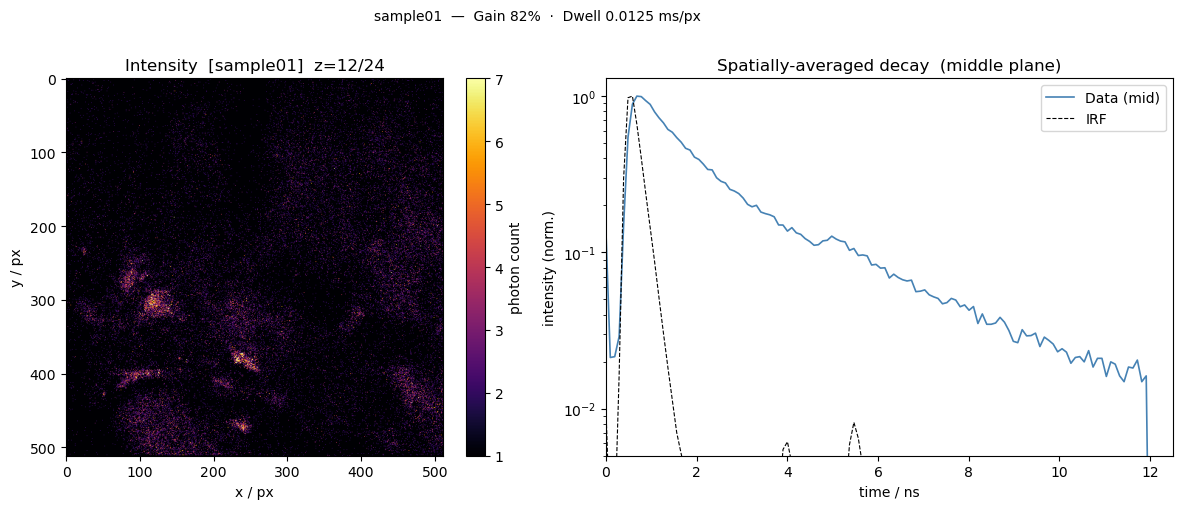

In [ ]:
import tkinter as tk
from tkinter import filedialog
import glob
import re
import warnings
import tifffile

# ── analysis parameters (edit per experiment) ─────────────────────────────────
Tcycle    = 12.5      # fallback if no .fbs.xml is found — overridden automatically
threshold = 3
newFolder = 'X:/FLIM_2026/results'
FName     = 'sample01'
limits    = np.array([np.nan, np.nan])
szPhs     = 0.005
szBin     = 3

thresh_norm    = 0.55   # mask threshold on 3D-normalised sumTCSPC [0–1]
nlm_h          = None   # NLM filter strength; None = auto (0.8 × estimated σ)
nlm_patch_size = 5      # NLM patch radius (voxels)
nlm_patch_dist = 6      # NLM search-window radius (voxels)
nlm_fast       = True   # fast_mode: ~10× speedup, negligible quality loss
rb_radius      = 50    # rolling ball radius (pixels, per z-slice)

os.makedirs(newFolder, exist_ok=True)

# ── TIFF dimension order ───────────────────────────────────────────────────────
dim_data = 'TYX'
dim_irf  = 'TYX'

# ── file / folder pickers ──────────────────────────────────────────────────────
def _pick_file(title):
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    p = filedialog.askopenfilename(
        title=title, filetypes=[('TIFF files', '*.tif *.tiff'), ('All files', '*.*')])
    root.destroy()
    return p or None

def _pick_folder(title):
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    p = filedialog.askdirectory(title=title)
    root.destroy()
    return p or None

# ── natural sort (handles z001, z002, … z010 correctly) ───────────────────────
def _natural_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

# ── XML search helper ──────────────────────────────────────────────────────────
def _find_xml(tiff_path):
    base = re.sub(r'_Intensity.*$', '', os.path.splitext(os.path.basename(tiff_path))[0])
    for search_dir in [os.path.dirname(os.path.dirname(tiff_path)), os.path.dirname(tiff_path)]:
        hits = sorted(glob.glob(os.path.join(search_dir, '*.fbs.xml')))
        if hits:
            return max(hits, key=lambda p: len(os.path.commonprefix([base, os.path.basename(p)])))
    return None

# ── axis-reorder helper ────────────────────────────────────────────────────────
def _to_yxt(arr, order):
    order = list(order.upper())
    extra = [i for i, c in enumerate(order) if c not in ('T', 'Y', 'X')]
    if extra:
        arr   = arr.sum(axis=tuple(sorted(extra)))
        order = [c for c in order if c in ('T', 'Y', 'X')]
    y, x, t = order.index('Y'), order.index('X'), order.index('T')
    return np.transpose(arr, [y, x, t])

# ── select IRF ────────────────────────────────────────────────────────────────
print('Select IRF TIFF  (dialog opening...)')
irf_path = _pick_file('Select IRF TIFF')
print(f'  IRF:  {irf_path}')

# ── select data folder (z-stack: all TIFs in folder) ──────────────────────────
print('Select DATA FOLDER  (dialog opening...)')
data_folder = _pick_folder('Select folder containing data TIFFs (z-stack)')
if not data_folder:
    raise RuntimeError('No data folder selected.')

data_paths = sorted(
    glob.glob(os.path.join(data_folder, '*.tif')) +
    glob.glob(os.path.join(data_folder, '*.tiff')),
    key=_natural_key)
n_planes = len(data_paths)
mid_idx  = n_planes // 2
print(f'\nFound {n_planes} planes in:  {data_folder}')
print(f'Middle plane  z={mid_idx}:  {os.path.basename(data_paths[mid_idx])}')

# ── load IRF metadata ──────────────────────────────────────────────────────────
meta_irf = None
xml_irf  = _find_xml(irf_path)
if xml_irf:
    meta_irf = read_fbs_metadata(xml_irf)
    print(f'\nIRF metadata:  {os.path.basename(xml_irf)}')
    print(f'  Tcycle={meta_irf["Tcycle"]:.4f} ns  nbin={meta_irf["nbin"]}  '
          f'gain={meta_irf["detector_gain"]}%  dwell={meta_irf["dwell_time_ms"]} ms/px')
else:
    print('\n  No .fbs.xml found for IRF')

# ── load metadata from middle plane (shared for all z-positions) ───────────────
meta     = None
xml_data = _find_xml(data_paths[mid_idx])
if xml_data:
    meta   = read_fbs_metadata(xml_data)
    Tcycle = meta['Tcycle']
    print(f'\nData metadata: {os.path.basename(xml_data)}')
    print(f'  Tcycle={Tcycle:.4f} ns  nbin={meta["nbin"]}  '
          f'pixel={meta["pixel_size_um"]:.4f} µm  '
          f'gain={meta["detector_gain"]}%  dwell={meta["dwell_time_ms"]} ms/px  '
          f'excitation={meta["excitation_nm"]} nm')
else:
    warnings.warn('No .fbs.xml found for data — using manual Tcycle.', RuntimeWarning, stacklevel=2)
    print(f'\n  No XML found — using manual Tcycle = {Tcycle} ns')

# ── Tcycle cross-check ────────────────────────────────────────────────────────
if meta_irf and meta:
    _dt = abs(meta_irf['Tcycle'] - meta['Tcycle'])
    if _dt > 0.01:
        warnings.warn(
            f'Tcycle mismatch: IRF={meta_irf["Tcycle"]:.4f} ns, '
            f'data={meta["Tcycle"]:.4f} ns (diff={_dt:.4f} ns). Using data Tcycle.',
            RuntimeWarning, stacklevel=2)
        print(f'WARNING: Tcycle mismatch — IRF={meta_irf["Tcycle"]:.4f}, data={meta["Tcycle"]:.4f} ns')
    else:
        print(f'\nTcycle cross-check OK  ({meta_irf["Tcycle"]:.4f} vs {meta["Tcycle"]:.4f} ns,  '
              f'diff={_dt:.5f} ns)')
elif meta_irf and not meta:
    Tcycle = meta_irf['Tcycle']
    print(f'Using Tcycle from IRF XML: {Tcycle:.4f} ns')

_gain  = f"Gain {meta['detector_gain']}%"        if meta and meta['detector_gain']  is not None else ''
_dwell = f"Dwell {meta['dwell_time_ms']} ms/px"   if meta and meta['dwell_time_ms'] is not None else ''
meta_str = '  ·  '.join(s for s in [_gain, _dwell] if s)

# ── load IRF (1-D) ─────────────────────────────────────────────────────────────
IRF_raw = tifffile.imread(irf_path).astype(float)
IRF = (_to_yxt(IRF_raw, dim_irf).sum(axis=(0, 1))
       if any(c in dim_irf.upper() for c in ('Y', 'X')) else IRF_raw.ravel())

# ── load middle plane as reference DataTCSPC ──────────────────────────────────
data_raw  = tifffile.imread(data_paths[mid_idx]).astype(float)
DataTCSPC = _to_yxt(data_raw, dim_data)
print(f'\nMiddle-plane DataTCSPC shape: {DataTCSPC.shape}  (ny, nx, nbin)')

# ── nbin check ────────────────────────────────────────────────────────────────
nbin_data = DataTCSPC.shape[2]
for _label, _m in [('data XML', meta), ('IRF XML', meta_irf)]:
    if _m and _m['nbin'] is not None and nbin_data != _m['nbin']:
        warnings.warn(
            f'nbin mismatch ({_label}): data has {nbin_data} bins, XML says {_m["nbin"]}.',
            RuntimeWarning, stacklevel=2)
print(f'nbin = {nbin_data}  ✓')

sumTCSPC = DataTCSPC.sum(axis=2)
maskPMT  = (sumTCSPC >= threshold).astype(float)
maskPMT[maskPMT == 0] = np.nan

_flat  = sumTCSPC.ravel(); _flat = _flat[_flat > 0]
lo_pct = np.percentile(_flat, 1)
hi_pct = np.percentile(_flat, 99.9)

_nbin_d  = DataTCSPC.shape[2]
_tau_d   = np.arange(_nbin_d) * (Tcycle / _nbin_d)
_decay   = DataTCSPC.sum(axis=(0, 1)).astype(float)
_irf_d   = IRF[:_nbin_d] / IRF[:_nbin_d].max()
_decay_n = _decay / _decay.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(sumTCSPC, cmap='inferno', aspect='equal', origin='upper',
                    vmin=lo_pct, vmax=hi_pct)
axes[0].set_title(f'Intensity  [{FName}]  z={mid_idx}/{n_planes-1}', fontsize=12)
axes[0].set_xlabel('x / px'); axes[0].set_ylabel('y / px')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04).set_label('photon count')
axes[1].semilogy(_tau_d, _decay_n, color='steelblue', linewidth=1.2, label='Data (mid)')
axes[1].semilogy(_tau_d, _irf_d,   color='k', linewidth=0.8, linestyle='--', label='IRF')
axes[1].set_xlabel('time / ns'); axes[1].set_ylabel('intensity (norm.)')
axes[1].set_title('Spatially-averaged decay  (middle plane)', fontsize=12)
axes[1].set_xlim(0, Tcycle); axes[1].set_ylim(5e-3, 1.3)
axes[1].legend()
_suptitle = FName + (f'  —  {meta_str}' if meta_str else '')
plt.suptitle(_suptitle, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [3]:
## 3D sumTCSPC pre-processing: NLM + rolling ball → vol_norm_3d, mask3d
# Loads all planes, builds a 3D intensity volume, denoises with 3-D NLM,
# subtracts rolling-ball background per slice, normalises to [0,1], then
# thresholds at thresh_norm to produce the 3D mask used by the loop and
# the reference-plane analysis.

from skimage.restoration import denoise_nl_means as _nlm_fn
from skimage.restoration import rolling_ball as _rolling_ball_fn
from skimage.restoration import estimate_sigma as _esig_fn

# ── build 3D sumTCSPC volume (all planes, sum over time axis) ─────────────────
print(f'Loading {n_planes} planes...', end=' ', flush=True)
vol_sum3d = np.stack([
    _to_yxt(tifffile.imread(p).astype(float), dim_data).sum(axis=2)
    for p in data_paths
], axis=0).astype(np.float32)                          # (nz, ny, nx)
print(f'done.  Shape: {vol_sum3d.shape}')

# ── pre-normalise to [0, 1] so NLM h is scale-independent ────────────────────
_vlo_pre = np.percentile(vol_sum3d, 1)
_vhi_pre = np.percentile(vol_sum3d, 99)
_vol01   = np.clip((vol_sum3d - _vlo_pre) / (_vhi_pre - _vlo_pre), 0, 1).astype(np.float32)

# ── 3-D NLM (CPU) ─────────────────────────────────────────────────────────────
_sigma3d = float(_esig_fn(_vol01, average_sigmas=True, channel_axis=None))
_h3d     = 0.8 * _sigma3d if nlm_h is None else nlm_h
print(f'Noise σ ≈ {_sigma3d:.5f}   h = {_h3d:.5f}')
print('Running 3-D NLM (CPU)...', end=' ', flush=True)
_vol_nlm = _nlm_fn(_vol01, h=_h3d, patch_size=nlm_patch_size,
                   patch_distance=nlm_patch_dist, fast_mode=nlm_fast,
                   channel_axis=None).astype(np.float32)
print('done.')

# ── rolling ball BG subtraction (per z-slice) ─────────────────────────────────
print('Rolling ball...', end=' ', flush=True)
_vol_rb = np.empty_like(_vol_nlm)
for _iz in range(_vol_nlm.shape[0]):
    _bg = _rolling_ball_fn(_vol_nlm[_iz], radius=rb_radius, workers=-1)
    _vol_rb[_iz] = np.clip(_vol_nlm[_iz] - _bg, 0, None)
print('done.')

# ── final [0, 1] normalisation ────────────────────────────────────────────────
_vlo3d, _vhi3d = np.percentile(_vol_rb, 1), np.percentile(_vol_rb, 99)
vol_norm_3d = np.clip((_vol_rb - _vlo3d) / (_vhi3d - _vlo3d), 0, 1).astype(np.float32)

# ── 3D threshold mask ─────────────────────────────────────────────────────────
mask3d = vol_norm_3d >= thresh_norm            # (nz, ny, nx), bool

# ── save ──────────────────────────────────────────────────────────────────────
_out3d      = os.path.join(newFolder, f'{FName}_sumTCSPC_3Dfilt_norm.tif')
_out_mask3d = os.path.join(newFolder, f'{FName}_mask3d.tif')
tifffile.imwrite(_out3d, vol_norm_3d)
tifffile.imwrite(_out_mask3d, mask3d.astype(np.uint8))
print(f'Saved: {_out3d}')
print(f'Saved: {_out_mask3d}')
print(f'Valid voxels: {mask3d.sum():,} / {mask3d.size:,}  '
      f'({100 * mask3d.mean():.1f} %)  thresh_norm = {thresh_norm}')

# ── QC: middle plane ──────────────────────────────────────────────────────────
_fig3d, _axes3d = plt.subplots(1, 3, figsize=(18, 5), facecolor='black')
for _a in _axes3d:
    _a.set_facecolor('black')
_panels3d = [
    (vol_sum3d[mid_idx],            'raw sumTCSPC  (mid plane)'),
    (vol_norm_3d[mid_idx],          f'3D NLM + rolling ball  (mid plane)\nh={_h3d:.4f}  r={rb_radius}'),
    (mask3d[mid_idx].astype(float), f'mask  (thresh_norm = {thresh_norm})'),
]
for _a, (_img, _ttl) in zip(_axes3d, _panels3d):
    _im3d = _a.imshow(_img, cmap='inferno', aspect='equal', origin='upper')
    _a.set_title(_ttl, color='white', fontsize=10)
    _a.tick_params(colors='white')
    for _sp in _a.spines.values():
        _sp.set_edgecolor('white')
plt.colorbar(_im3d, ax=_axes3d[-1], fraction=0.046, pad=0.04).set_label('mask', color='white')
plt.suptitle(f'{FName}  —  3D sumTCSPC pre-processing  (z={mid_idx}/{n_planes-1})',
             color='white', fontsize=9)
plt.tight_layout()
plt.show()

Loading 25 planes... done.  Shape: (25, 512, 512)
Noise σ ≈ 0.15246   h = 0.12197
Running 3-D NLM (CPU)... done.
Rolling ball... 

KeyboardInterrupt: 

In [ ]:
## Cellpose 3D segmentation on vol_norm_3d
# Input: vol_norm_3d (NLM + rolling ball filtered, [0,1]) produced above.
# Tune cp_diameter first — it is the most important parameter.
# anisotropy = z_step / xy_pixel = 3.0 µm / 1.0 µm (update if your acquisition differs).

from cellpose import models as _cp_models

# ── parameters ────────────────────────────────────────────────────────────────
cp_diameter        = 30      # expected cell diameter in xy (pixels)
cp_anisotropy      = 3.0     # z_um / xy_um
cp_model_type      = 'cyto3' # 'cyto3' | 'cyto2' | 'nuclei'
cp_flow_threshold  = 0.4     # raise to accept more cells
cp_cellprob_thresh = 0.0     # lower = more cells detected
cp_gpu             = False

# ── run ───────────────────────────────────────────────────────────────────────
print(f'Running Cellpose 3D  model={cp_model_type}  diam={cp_diameter}px  '
      f'aniso={cp_anisotropy}  gpu={cp_gpu}...', flush=True)
_cp_model = _cp_models.Cellpose(gpu=cp_gpu, model_type=cp_model_type)
cp_masks, cp_flows, cp_styles, cp_diams = _cp_model.eval(
    vol_norm_3d,
    diameter=cp_diameter,
    channels=[0, 0],
    do_3D=True,
    anisotropy=cp_anisotropy,
    flow_threshold=cp_flow_threshold,
    cellprob_threshold=cp_cellprob_thresh,
)
n_cells = int(cp_masks.max())
print(f'Done.  {n_cells} cells found.')

# ── save ──────────────────────────────────────────────────────────────────────
_out_cp = os.path.join(newFolder, f'{FName}_cellpose_masks.tif')
tifffile.imwrite(_out_cp, cp_masks.astype(np.uint16))
print(f'Saved: {_out_cp}')

# ── QC: middle plane ──────────────────────────────────────────────────────────
_fig_cp, _axes_cp = plt.subplots(1, 2, figsize=(14, 6), facecolor='black')
for _a in _axes_cp:
    _a.set_facecolor('black')

_axes_cp[0].imshow(vol_norm_3d[mid_idx], cmap='inferno', aspect='equal', origin='upper')
_axes_cp[0].set_title(f'NLM intensity  z={mid_idx}', color='white', fontsize=11)

_n_lab   = max(n_cells, 1)
_cmap_cp = plt.colormaps.get_cmap('tab20').resampled(_n_lab)
_axes_cp[1].imshow(cp_masks[mid_idx], cmap=_cmap_cp, aspect='equal', origin='upper',
                   vmin=0, vmax=_n_lab, interpolation='nearest')
_axes_cp[1].set_title(f'Cellpose masks  z={mid_idx}  ({n_cells} cells)',
                       color='white', fontsize=11)

for _a in _axes_cp:
    _a.tick_params(colors='white')
    for _sp in _a.spines.values():
        _sp.set_edgecolor('white')
plt.suptitle(f'{FName}  —  Cellpose  model={cp_model_type}  '
             f'diam={cp_diameter} px  aniso={cp_anisotropy}',
             color='white', fontsize=9)
plt.tight_layout()
plt.show()

## Step 1-2: Mask preparation
Extracts the middle-plane slice of `vol_norm_3d` (3D NLM + rolling ball, computed above) and thresholds at `thresh_norm` to produce `maskTCSPC` (float, 0/1) and `maskFilt_bool` (boolean, for downstream use).

In [ ]:
from imageio import imwrite

# ── masks from 3D pre-processed volume (middle plane) ────────────────────────
maskTCSPC     = mask3d[mid_idx].astype(float)
maskFilt_bool = mask3d[mid_idx]

# ── save middle-plane intensity maps ─────────────────────────────────────────
imwrite(os.path.join(newFolder, f'{FName}_sumTCSPC.tif'), sumTCSPC.astype(np.float32))
imwrite(os.path.join(newFolder, f'{FName}_sumTCSPC_filt_norm.tif'),
        vol_norm_3d[mid_idx].astype(np.float32))

print(f'maskTCSPC valid pixels: {maskFilt_bool.sum():.0f}  (thresh_norm={thresh_norm})')

## Step 3: IRF preprocessing
1. Sum over spatial dims to get a 1-D IRF trace.
2. **Circular right-shift by 2 bins** (same as MATLAB `[IRF2(end-1:end); IRF2(1:end-2)]`).
3. Subtract median of last 25 bins (background) and clip negatives.

In [ ]:
IRF2 = IRF.sum(axis=tuple(range(IRF.ndim - 1))) if IRF.ndim > 1 else IRF.copy()
IRF2 = IRF2.ravel().astype(float)
Ix   = len(IRF2)

# IRF2 = np.roll(IRF2, 2)           # 2-bin right-shift -- legacy from old instrument, not needed
IRF2 = IRF2 - np.median(IRF2[-25:]) # subtract background (median of last 25 bins)
IRF2 = IRF2 + np.abs(IRF2.min())    # clip negatives to zero

print(f'IRF bins (Ix): {Ix}')
print(f'IRF peak at bin {np.argmax(IRF2)},  max = {IRF2.max():.1f}')


## Step 4: Bin alignment
Compares the number of time bins in the data vs the IRF and resolves the mismatch:
- **IRF has more bins** -> average the IRF down to `nbin` data bins.
- **Data has more bins** -> reshape extra bins as repetitions (becomes 4th dimension).

In [ ]:
# ── Bin alignment -- not needed for new instrument (nbin_data == Ix assumed) ──
# nbin_data = DataTCSPC.shape[2]
# nbin      = min(nbin_data, Ix)
#
# if nbin < Ix:
#     nrep = int(Ix // nbin)
#     IRF2 = IRF2[:nbin * nrep].reshape(nrep, nbin).mean(axis=0)
#     print(f'IRF averaged: {Ix} -> {nbin} bins  (nrep={nrep})')
# else:
#     nbin   = Ix
#     nx_d, ny_d = DataTCSPC.shape[0], DataTCSPC.shape[1]
#     nrep   = int(nbin_data // nbin)
#     DataTCSPC = DataTCSPC[:, :, :nbin * nrep]
#     DataTCSPC = DataTCSPC.reshape(nx_d, ny_d, nrep, nbin).swapaxes(2, 3)
#     print(f'Data reshaped: {nbin_data} -> ({nbin} bins x {nrep} reps)')
#
# print(f'nbin = {nbin},  DataTCSPC shape = {DataTCSPC.shape}')


In [ ]:
## Step 4b: Peak realignment
# Circularly shifts DataTCSPC and IRF2 so both peaks land at 8% of nbin.

import warnings

# ── bin count check ───────────────────────────────────────────────────────────
nbin_data = DataTCSPC.shape[2]
if nbin_data != Ix:
    warnings.warn(
        f'Bin count mismatch: DataTCSPC has {nbin_data} bins, IRF has {Ix} bins. '
        'Check dim_data / dim_irf — bin alignment (code-06) may need re-enabling.',
        RuntimeWarning, stacklevel=2)
nbin = nbin_data
dt   = Tcycle / nbin
tau  = np.arange(1, nbin + 1) * dt
print(f'nbin = {nbin},  dt = {dt:.4f} ns')

# ── target frame: 8% of nbin ─────────────────────────────────────────────────
target = int(round(0.08 * nbin))
print(f'Target peak frame: {target} / {nbin}  ({100 * target / nbin:.1f}%)')

# ── pixel mask ────────────────────────────────────────────────────────────────
maskPixel    = mask3d[mid_idx]
decay_masked = DataTCSPC[maskPixel].sum(axis=0).astype(float)

# ── shift DataTCSPC so fluorescence peak → target frame ──────────────────────
peak_data  = int(np.argmax(decay_masked))
shift_data = target - peak_data
DataTCSPC  = np.roll(DataTCSPC, shift_data, axis=2)
print(f'Data  peak was frame {peak_data:3d},  shifted by {shift_data:+d}')

# ── shift IRF2 so its peak → target frame ────────────────────────────────────
peak_irf  = int(np.argmax(IRF2))
shift_irf = target - peak_irf
IRF2      = np.roll(IRF2, shift_irf)
print(f'IRF   peak was frame {peak_irf:3d},  shifted by {shift_irf:+d}')

# ── sanity-check plot ─────────────────────────────────────────────────────────
_decay_aligned = DataTCSPC[maskPixel].sum(axis=0).astype(float)
_decay_n       = _decay_aligned / _decay_aligned.max()
_irf_n         = IRF2 / IRF2.max()

fig_align, ax_align = plt.subplots(figsize=(7, 4))
ax_align.semilogy(tau, _irf_n, '--k', linewidth=0.8, label='IRF')
ax_align.semilogy(tau, _decay_n, color='steelblue', linewidth=1.2,
                  label=f'Data  ({maskPixel.sum()} px)')
ax_align.axvline(tau[target], color='orange', linewidth=1, linestyle=':',
                 label=f'target  frame {target}')
ax_align.set_xlabel('time / ns')
ax_align.set_ylabel('intensity (norm.)')
ax_align.set_title(f'After realignment  [{FName}]' + (f'\n{meta_str}' if meta_str else ''),
                   fontsize=10)
ax_align.set_xlim(0, Tcycle)
ax_align.set_ylim(5e-3, 1.3)
ax_align.legend()
fig_align.tight_layout()
plt.show()

## Step 5-6: Circular shift, time axis, normalised traces
Shifts data by 2 bins (same as IRF), builds the time axis `tau`, and computes the normalised photon-per-bin traces used for alignment and fitting.

In [ ]:
# DataTCSPC = np.roll(DataTCSPC, 2, axis=2)   # 2-bin shift -- not needed for new instrument

dt  = Tcycle / nbin
tau = np.arange(1, nbin + 1) * dt               # time axis (ns)

# masked average decay (pixels >= threshold) -- consistent with maskPixel
# convert maskTCSPC to boolean for indexing, but keep original maskPixel for stats
maskTCSPCbool = maskTCSPC.astype(bool)
tmp1 = DataTCSPC[maskPixel].sum(axis=0).astype(float)

tmp = tmp1 / tmp1.max()
irf = IRF2 / IRF2.max()

print(f'dt = {dt:.4f} ns,  tau: {tau[0]:.3f} to {tau[-1]:.3f} ns')
print(f'Total photons in masked area: {tmp1.sum():.0f}  ({maskPixel.sum()} pixels)')


## Step 7-8: Align IRF peak to data peak + decay plot
Shifts the IRF so its peak coincides with the data peak, then plots both on a semilog y-axis.

In [ ]:
# ── IRF-to-data peak alignment (replaced by realignment cell -- kept for reference)
# xs1 = int(np.argmax(irf))
# xs2 = int(np.argmax(tmp))
# if xs1 > xs2:
#     shift = xs1 - xs2
#     irf   = np.concatenate([irf[shift:],   np.zeros(shift)])
#     IRF2  = np.concatenate([IRF2[shift:],  np.zeros(shift)])
#     print(f'IRF shifted left by {shift} bins')
# elif xs1 < xs2:
#     shift = xs2 - xs1
#     irf   = np.concatenate([np.zeros(shift), irf[:-shift]])
#     IRF2  = np.concatenate([np.zeros(shift), IRF2[:-shift]])
#     print(f'IRF shifted right by {shift} bins')
# else:
#     print('Peaks already aligned')

# fig_lt, ax_lt = plt.subplots(figsize=(7, 4))
# ax_lt.semilogy(tau, irf, '--k', linewidth=0.5, label='IRF')
# ax_lt.semilogy(tau, tmp, ':o', markersize=4, markerfacecolor='b', color='b', label='Data')
# ax_lt.set_ylabel('signal / a.u.')
# ax_lt.set_xlabel('time / ns')
# ax_lt.set_xlim(0, np.ceil(Tcycle))
# ax_lt.set_ylim(5e-3, 1.2)
# ax_lt.legend()
# fig_lt.suptitle(f'LT Data & IRF  {FName}')
# plt.tight_layout()
# plt.show()


## Step 9: Apply count-threshold mask
Zeroes out pixels below `threshold` photon counts before the lifetime computation.

In [ ]:
bc = (slice(None), slice(None)) + (np.newaxis,) * (DataTCSPC.ndim - 2)
DataTCSPC = DataTCSPC * maskTCSPC[bc]
print(f'Pixels zeroed out: {(maskTCSPC == 0).sum():.0f}')

## Step 10: Core lifetime math -- mean arrival time
**Key equations:**
- `H = sum(tau * IRF) / sum(IRF)` -- mean arrival time of the IRF (instrument offset, scalar)
- `F[x,y] = sum(tau * data[x,y]) / sum(data[x,y])` -- mean photon arrival time per pixel
- `tav = F - H` -- fluorescence lifetime estimate per pixel (ns)

In [ ]:
DataTCSPC = DataTCSPC.astype(float)
if DataTCSPC.ndim == 3:
    DataTCSPC = DataTCSPC[:, :, :, np.newaxis]

nx, ny, nbin, nch = DataTCSPC.shape
T = tau[np.newaxis, np.newaxis, :, np.newaxis]

H = float(np.dot(tau, IRF2) / IRF2.sum())

F = (T * DataTCSPC).sum(axis=2) / DataTCSPC.sum(axis=2)
F = np.nan_to_num(F)

tag = DataTCSPC.sum(axis=2).squeeze()
tav = (F - H).squeeze()
tav = np.clip(tav, 0, None)

print(f'H (IRF mean arrival time): {H:.4f} ns')
valid_tav = tav[maskTCSPCbool & (tav > 0)]
if valid_tav.size > 0:
    print(f'tav stats (masked) -- min: {valid_tav.min():.3f} ns,  '
          f'mean: {valid_tav.mean():.3f} ns,  max: {valid_tav.max():.3f} ns')

_tav_disp = tav.copy().astype(float)
_tav_disp[~maskTCSPCbool] = np.nan
_pos = _tav_disp[np.isfinite(_tav_disp) & (_tav_disp > 0)]
_vmin = float(np.percentile(_pos,  1)) if _pos.size else 0.0
_vmax = float(np.percentile(_pos, 90)) if _pos.size else 1.0

fig, ax = plt.subplots(figsize=(6, 5), facecolor='black')
ax.set_facecolor('black')
im = ax.imshow(_tav_disp, cmap='gnuplot2', aspect='equal', origin='upper',
               vmin=_vmin, vmax=_vmax)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('tav / ns', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.outline.set_visible(False)
ax.set_title(f'Mean arrival-time lifetime  [{FName}]' + (f'\n{meta_str}' if meta_str else ''),
             fontsize=10, color='white')
ax.set_xlabel('x / px', color='white')
ax.set_ylabel('y / px', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
plt.tight_layout()
plt.show()

## Step 10b: Bilateral filter on tav
Edge-preserving smooth of the lifetime map. The spatial σ controls neighbourhood size; the range σ (in ns) controls how much lifetime difference is tolerated before a neighbour is down-weighted — so sharp boundaries between compartments with different lifetimes are preserved while shot-noise within a compartment is averaged out. Overwrites `tav` in place; skip this cell to keep the raw map.

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────
sigma_spatial   = 4.0   # spatial Gaussian σ (pixels)   — larger = more smoothing
sigma_lifetime  = 0.4   # range σ (ns) — lifetimes within this are averaged;
                        #   increase to smooth across compartments, decrease to sharpen edges

# calc std of tav for later use in range-based filtering (optional)
tav_std = np.nanstd(tav[maskTCSPCbool & (tav > 0)])
print(f'tav std (masked, positive pixels): {tav_std:.3f} ns')
sigma_lifetime = max(sigma_lifetime, 0.5 * tav_std)
print(f'Using σ_lifetime = {sigma_lifetime:.3f} ns for bilateral filter')

# ── apply ─────────────────────────────────────────────────────────────────────
# Mask invalid pixels as NaN so they are excluded from their neighbours' averages.
_tav_in = tav.copy().astype(float)
_tav_in[~maskTCSPCbool] = np.nan

_tav_filled = np.where(np.isfinite(_tav_in), _tav_in, float(np.nanmean(_tav_in)))
_tav_filt   = denoise_bilateral(_tav_filled, sigma_color=sigma_lifetime,
                                sigma_spatial=sigma_spatial, channel_axis=None)
_tav_filt[~maskTCSPCbool] = np.nan

# ── percentile range over positive pixels only (zeros are clipped negatives) ──
_pos = _tav_in[np.isfinite(_tav_in) & (_tav_in > 0)]
_vmin = float(np.percentile(_pos,  20)) if _pos.size else 0.0
_vmax = float(np.percentile(_pos, 80)) if _pos.size else 1.0

# ── side-by-side comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')
for ax in axes:
    ax.set_facecolor('black')

axes[0].imshow(_tav_in,   cmap='gnuplot2', aspect='equal', origin='upper', vmin=_vmin, vmax=_vmax)
axes[0].set_title('tav  (raw)', fontsize=11, color='white')
im = axes[1].imshow(_tav_filt, cmap='gnuplot2', aspect='equal', origin='upper', vmin=_vmin, vmax=_vmax)
axes[1].set_title(f'tav  (bilateral  σ_spatial={sigma_spatial} px, σ_range={sigma_lifetime} ns)',
                  fontsize=11, color='white')

cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('tav / ns', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.outline.set_visible(False)

for ax in axes:
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

_sup = FName + (f'  —  {meta_str}' if meta_str else '')
plt.suptitle(_sup, fontsize=9, y=1.01, color='white')
plt.tight_layout()
plt.show()

# overwrite tav so downstream cells (FLIM image, metrics) use the filtered map
tav = _tav_filt
print(f'tav updated  (bilateral filtered).  '
      f'Mean: {np.nanmean(tav):.3f} ns,  std: {np.nanstd(tav):.3f} ns')

## Step 11: False-colour FLIM image
Auto-determines lifetime display range with `uplowthresh` (if `limits` is NaN), then calls `FastFLIM_mod_AT0` to generate and display the image.

In [ ]:
saveLTimg = os.path.join(newFolder, FName)
# limits    = np.asarray(limits, dtype=float) # only needed if run on loop (get the first limits value, then reuse for consistent scaling across images)
limits    = np.array([np.nan, np.nan])
if np.all(np.isnan(limits)):
    ind = tag < threshold
    if not np.any(~ind):
        ind = tag < 1
    tim_auto = tav.copy()
    tim_auto[ind] = 0
    hi1, lo1 = uplowthresh(tim_auto, 0.95, 0.05)
    limits = np.array([lo1, hi1])
    print(f'Auto limits: [{limits[0]:.3f}, {limits[1]:.3f}] ns')

LTImg, Bar = FastFLIM_mod_AT0(saveLTimg, tag, tav, threshold, limits)

## Step 12: Exponential decay fitting
`Fit_decay` fits a multi-exponential model to the spatially-averaged decay `tmp1`:
1. Grid search over fractional IRF shift (-5 to +5 bins, step 0.5)
2. NNLS on amplitude distribution -> component groups -> initial lifetime guesses
3. Cascade Nelder-Mead optimization (10 cascades x 10 perturbations, shrinking spread)

The fitted model is overlaid on the IRF/data plot from Step 7-8.

In [ ]:
tau2, amp2, off2, z2, chi2_2, model2 = Fit_decay(IRF2, tmp1, Tcycle, dt)

# overlay fitted model on the decay plot from Step 7-8
peak = int(np.argmax(tmp))
if model2 is not None and model2.max() > 0:
    model2N = model2 / model2.max()
    ax_lt.semilogy(tau[peak:], model2N[peak:], 'g', linewidth=1.2, label='Fit_decay')
    ax_lt.legend()
    fig_lt.canvas.draw()

# amplitude-weighted lifetime
valid_mask = amp2 > 0
aw_LT2 = (float(np.dot(tau2[valid_mask], amp2[valid_mask]) / amp2[valid_mask].sum())
          if valid_mask.any() and amp2[valid_mask].sum() != 0 else np.nan)

# cap to 5 components for storage
tau2     = np.asarray(tau2).ravel()[:5]
amp2     = np.asarray(amp2).ravel()[:5]
tau_tmp2 = np.zeros(5); tau_tmp2[:len(tau2)] = tau2
amp_tmp2 = np.zeros(5); amp_tmp2[:len(amp2)] = amp2

print(f'Fit_decay:  chi2 = {chi2_2:.4f},  aw_LT = {aw_LT2:.4f} ns')
for i, (t_, a_) in enumerate(zip(tau2, amp2)):
    if a_ > 0:
        print(f'  Component {i+1}: tau = {t_:.4f} ns,  amp = {a_:.4f}')

## Step 13: Phasor analysis + reference correction
Two-step workflow:
1. **Raw phasors** — `Calc_Phasor_Mat` is called twice: once on the IRF (reshaped to a 1×1 image, used as the reference with known tau = 0 ns) and once on the sample data.
2. **Reference correction** — `phasor_ref_correction` uses the IRF phasor to compute a modulation scale factor (`M_cor`) and a phase rotation (`phi_cor`) that map the IRF to its theoretical position (G=1, S=0), then applies those corrections to the sample G/S coordinates. This removes instrument modulation attenuation and phase offsets. The corrected coordinates are in `G_corr`/`S_corr`; per-pixel lifetime maps from phase (`tau_phi`) and modulation (`tau_mod`) are also returned.

In [ ]:
fig_name0 = os.path.join(newFolder, FName + '_Phas.png')
freq_mhz  = 1000.0 / Tcycle

try:
    # Step 1a: IRF reference phasor — computed directly instead of via Calc_Phasor_Mat.
    # Calc_Phasor_Mat masks pixels where G < 0 or S < 0, but the IRF can have a slightly
    # negative S due to its asymmetric shape (sharp rise, slower tail), which would produce
    # NaN and break the correction. The formula mirrors what Calc_Phasor_Mat does internally.
    tau_p = (np.arange(1, nbin + 1) - 0.5) * dt
    ph    = np.dot(tau_p, IRF2) / IRF2.sum()
    T_irf = 2.0 * np.pi * (tau_p - ph) / Tcycle
    w_irf = IRF2 / IRF2.sum()
    G_ref = np.array([[float(np.dot(np.cos(T_irf), w_irf))]])
    S_ref = np.array([[float(np.dot(np.sin(T_irf), w_irf))]])
    print(f'IRF phasor:  G_ref = {G_ref[0,0]:.4f},  S_ref = {S_ref[0,0]:.4f}')

    # Step 1b: raw phasor of sample data (pass None to skip saving — corrected plot is saved in 13b)
    S, G, M = Calc_Phasor_Mat(IRF2, DataTCSPC, Tcycle, dt, szPhs, None,
                               min_count=threshold, spatial_bin=szBin)

    # Step 2: reference correction — maps IRF to (G=1, S=0), applies same
    # modulation scale and phase rotation to the sample coordinates.
    G_corr, S_corr, tau_mod, tau_phi = phasor_ref_correction(
        G, S, G_ref, S_ref, tau_ref_ns=0.0, freq_mhz=freq_mhz)

except Exception as e:
    print(f'Phasor failed: {e}')
    nbin3 = int(round(1.0 / szPhs)) + 1
    M = np.zeros((nbin3, nbin3))
    S = G = G_corr = S_corr = tau_mod = tau_phi = None

Phasor0 = M[::-1]
print(f'Phasor matrix shape: {Phasor0.shape}')
if G is not None:
    print(f'G raw  : [{np.nanmin(G):.3f}, {np.nanmax(G):.3f}]   '
          f'S raw  : [{np.nanmin(S):.3f}, {np.nanmax(S):.3f}]')
if G_corr is not None:
    print(f'G corr : [{np.nanmin(G_corr):.3f}, {np.nanmax(G_corr):.3f}]   '
          f'S corr : [{np.nanmin(S_corr):.3f}, {np.nanmax(S_corr):.3f}]')
    valid_phi = tau_phi[np.isfinite(tau_phi)] if tau_phi is not None else np.array([])
    if valid_phi.size:
        print(f'tau_phi: [{valid_phi.min():.3f}, {valid_phi.max():.3f}] ns')

## Step 13b: Corrected phasor plot
Plots the IRF-corrected G/S coordinates as a 2-D density on the universal semicircle.
Lifetime tick marks are computed from the laser frequency (`freq_mhz`) so they land at the correct positions for your repetition rate.

In [ ]:
if G_corr is None or S_corr is None:
    print('No corrected phasor data — re-run Step 13 first.')
else:
    gv = G_corr.ravel(); sv = S_corr.ravel()
    ok = np.isfinite(gv) & np.isfinite(sv)
    gv, sv = gv[ok], sv[ok]

    nbin_p = int(round(1.0 / szPhs)) + 1
    X_idx  = np.round(gv / szPhs).astype(int)
    Y_idx  = np.round(sv / szPhs).astype(int)
    M_corr = np.zeros((nbin_p, nbin_p))
    ok2    = (X_idx >= 0) & (X_idx < nbin_p) & (Y_idx >= 0) & (Y_idx < nbin_p)
    np.add.at(M_corr, (Y_idx[ok2], X_idx[ok2]), 1)

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    if M_corr.max() > 0:
        vmax = np.percentile(M_corr[M_corr > 0], 99)
        cmap = plt.cm.jet.copy(); cmap.set_under('white')
        ax.imshow(np.flipud(M_corr), extent=[0, 1, 0, 1], aspect='equal',
                  cmap=cmap, origin='upper', vmin=1, vmax=vmax)

    theta = np.linspace(0, np.pi, 400)
    ax.plot(0.5 + 0.5 * np.cos(theta), 0.5 * np.sin(theta), '-', color='black', linewidth=1.5)

    omega = 2.0 * np.pi * freq_mhz * 1e6
    for tau_tick_ns in [0.5, 1, 2, 4, 8]:
        wt  = omega * tau_tick_ns * 1e-9
        g_t = 1.0 / (1.0 + wt ** 2); s_t = wt / (1.0 + wt ** 2)
        ax.plot(g_t, s_t, 'o', color='black', markersize=5, zorder=5)
        ax.annotate(f'{tau_tick_ns} ns', xy=(g_t, s_t), color='black',
                    fontsize=8, xytext=(5, 3), textcoords='offset points')

    ax.set_xlim(0, 1.0); ax.set_ylim(0, 0.8); ax.set_aspect('equal')
    ax.set_xlabel('G  (corrected)', fontweight='bold', fontsize=14, fontstyle='italic')
    ax.set_ylabel('S  (corrected)', fontweight='bold', fontsize=14, fontstyle='italic')
    ax.tick_params(labelsize=11)

    _title = f'Phasor — IRF corrected  |  {ok.sum()} points  [{FName}]'
    ax.set_title(_title + (f'\n{meta_str}' if meta_str else ''), fontsize=10)

    plt.tight_layout()
    fig_phas_corr = os.path.join(newFolder, FName + '_Phas_corr.png')
    plt.savefig(fig_phas_corr, facecolor='white', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_phas_corr}')

## Step 14: Lifetime summary metrics
Three independent scalar estimates derived from `tav`:
- **Tau_av** (Method 1): mean of PMT-masked pixels where `tav > H/2`
- **Tau_norm** (Method 3): mean photon arrival time in the whole signal area minus H
- **Tau_mask** (Method 4): mean tav after re-applying the PMT mask to the photon data

In [ ]:
# Method 1 -- mean tav of PMT-masked pixels where tav > H/2
Tau_1  = tav * maskPMT
valid  = Tau_1[Tau_1 > (H / 2)]
Tau_av = float(np.nanmean(valid)) if valid.size > 0 else np.nan

# Method 3 -- mean photon arrival time across signal area minus H
Tau_norm = float(np.dot(tau, tmp1) / tmp1.sum() - H)

# Method 4 -- tav mean after re-masking photon data with PMT mask
DT_masked = DataTCSPC * maskPMT[:, :, np.newaxis, np.newaxis]
F1        = np.nansum(T * DT_masked, axis=2) / np.nansum(DT_masked, axis=2)
tav2      = np.clip((F1 - H).squeeze(), 0, None)
Tau_mask  = float(np.nanmean(tav2))

print(f'Tau_av   (Method 1 -- PMT mask, tav > H/2):  {Tau_av:.4f} ns')
print(f'Tau_norm (Method 3 -- area mean - H):         {Tau_norm:.4f} ns')
print(f'Tau_mask (Method 4 -- PMT-masked tav mean):   {Tau_mask:.4f} ns')

## Save and collect results

In [ ]:
# save LT figure
fig_name1 = os.path.join(newFolder, FName + '_LT.png')
fig_lt.savefig(fig_name1)
print(f'LT figure saved: {fig_name1}')

# collect outputs
Dcays1   = {'ns': tau, 'irf_counts': IRF2}
Dcays2   = {'tmp1': tmp1, 'model': model2}
lifetime = {
    'Tau_av':   Tau_av,
    'Tau_mask': Tau_mask,
    'Tau_norm': Tau_norm,
    'tau_tmp2': tau_tmp2,
    'amp_tmp2': amp_tmp2,
    'aw_LT2':   aw_LT2,
    'chi2':     chi2_2,
}

print()
print('=== Lifetime summary ===')
for k, v in lifetime.items():
    print(f'  {k:12s}: {v}')

## Z-stack loop
Processes **all planes** in `data_paths` through the full pipeline.  
`limits` (colourmap range) are fixed from the middle plane computed in Steps 1–11 above — run those cells first.  

**Outputs per plane**
| File | Content |
|------|---------|
| `*_sumTCSPC_stack.tif` | Raw photon-count maps (float32, multi-page) |
| `*_sumTCSPC_filt_norm_stack.tif` | Filtered + normalised intensity (float32, multi-page) |
| `*_mask_stack.tif` | Threshold masks (float32, multi-page) |
| `*_tav_raw_stack.tif` | Per-pixel mean-arrival-time lifetime before bilateral filter |
| `*_tav_filt_stack.tif` | Bilateral-filtered lifetime (NaN = masked) |
| `*_FLIM_RGB_stack.tif` | False-colour RGB volume (uint8, multi-page) |
| `*_z###_LTimg.png` | Per-plane false-colour FLIM image |
| `*_z###_decay.png` | Per-plane aligned decay plot |
| `*_FLIM_limits.csv` | Colourmap limits (lo/hi ns) from middle plane |

In [ ]:
import csv
import importlib
import FastFLIM_mod_AT0 as _ffm_module
importlib.reload(_ffm_module)
from FastFLIM_mod_AT0 import FastFLIM_mod_AT0

# ── output stack paths ─────────────────────────────────────────────────────────
def _sp(tag): return os.path.join(newFolder, f'{FName}_{tag}.tif')
stack_sum      = _sp('sumTCSPC_stack')
stack_norm     = _sp('sumTCSPC_filt_norm_stack')
stack_mask     = _sp('mask_stack')
stack_tav_raw  = _sp('tav_raw_stack')
stack_tav_filt = _sp('tav_filt_stack')
stack_rgb      = _sp('FLIM_RGB_stack')

for _p in [stack_sum, stack_norm, stack_mask, stack_tav_raw, stack_tav_filt, stack_rgb]:
    if os.path.exists(_p): os.remove(_p)

# ── save colourmap limits to CSV ──────────────────────────────────────────────
csv_path = os.path.join(newFolder, f'{FName}_FLIM_limits.csv')
with open(csv_path, 'w', newline='') as _f:
    _w = csv.writer(_f)
    _w.writerow(['lo_ns', 'hi_ns', 'source_plane'])
    _w.writerow([f'{limits[0]:.4f}', f'{limits[1]:.4f}', f'z={mid_idx}'])
print(f'Limits  {limits[0]:.4f} – {limits[1]:.4f} ns  (from z={mid_idx})  →  {csv_path}')

# ── constants shared across all planes ────────────────────────────────────────
H    = float(np.dot(tau, IRF2) / IRF2.sum())
T_4d = tau[np.newaxis, np.newaxis, :, np.newaxis]
print(f'\nH = {H:.4f} ns  |  target frame = {target}  |  {n_planes} planes to process\n')

# ── open all TiffWriters once — keeps planes in the same series ───────────────
_tw_sum  = tifffile.TiffWriter(stack_sum)
_tw_norm = tifffile.TiffWriter(stack_norm)
_tw_mask = tifffile.TiffWriter(stack_mask)
_tw_traw = tifffile.TiffWriter(stack_tav_raw)
_tw_tflt = tifffile.TiffWriter(stack_tav_filt)
_tw_rgb  = tifffile.TiffWriter(stack_rgb)

try:
    # ══════════════════════════════════════════════════════════════════════════
    for z, path in enumerate(data_paths):

        # ── 1. Load plane ──────────────────────────────────────────────────────
        _raw  = tifffile.imread(path).astype(float)
        DataZ = _to_yxt(_raw, dim_data)
        sumZ  = DataZ.sum(axis=2)

        # ── 2. Mask from 3D pre-processed volume ──────────────────────────────
        maskZ_bool = mask3d[z]
        maskZ      = maskZ_bool.astype(float)
        sumZ_norm  = vol_norm_3d[z]   # NLM-filtered intensity, [0,1] — used as brightness tag

        # ── 3. Bin alignment ──────────────────────────────────────────────────
        _decay_z = DataZ[maskZ_bool].sum(axis=0).astype(float)
        shift_z  = target - int(np.argmax(_decay_z))
        DataZ    = np.roll(DataZ, shift_z, axis=2)

        # ── 4. Decay plot — saved, not displayed ──────────────────────────────
        _dec_n = DataZ[maskZ_bool].sum(axis=0).astype(float)
        _dec_n = _dec_n / _dec_n.max()
        _irf_n = IRF2 / IRF2.max()
        _fig_d, _ax_d = plt.subplots(figsize=(6, 3.5))
        _ax_d.semilogy(tau, _irf_n, '--k', lw=0.8, label='IRF')
        _ax_d.semilogy(tau, _dec_n, color='steelblue', lw=1.2, label=f'z={z:03d}')
        _ax_d.axvline(tau[target], color='orange', lw=0.8, ls=':')
        _ax_d.set_xlabel('time / ns'); _ax_d.set_ylabel('norm. intensity')
        _ax_d.set_title(f'Aligned decay  [{FName}]  z={z:03d}/{n_planes-1}', fontsize=9)
        _ax_d.set_xlim(0, Tcycle); _ax_d.set_ylim(5e-3, 1.3); _ax_d.legend(fontsize=8)
        _fig_d.tight_layout()
        _fig_d.savefig(os.path.join(newFolder, f'{FName}_z{z:03d}_decay.png'),
                       dpi=100, bbox_inches='tight')
        plt.close(_fig_d)

        # ── 5. Write intensity / mask planes ──────────────────────────────────
        _tw_sum.write(sumZ.astype(np.float32))
        _tw_norm.write(sumZ_norm.astype(np.float32))
        _tw_mask.write(maskZ.astype(np.float32))

        # ── 6. Apply mask and compute tav ─────────────────────────────────────
        DataZ = (DataZ * maskZ[:, :, np.newaxis]).astype(float)[:, :, :, np.newaxis]
        _F_z  = np.nan_to_num((T_4d * DataZ).sum(axis=2) / DataZ.sum(axis=2))
        tav_z = np.clip((_F_z - H).squeeze(), 0, None)
        _tw_traw.write(tav_z.astype(np.float32))

        # ── 7. Bilateral filter ───────────────────────────────────────────────
        _tav_in = tav_z.copy(); _tav_in[~maskZ_bool] = np.nan
        _fill   = float(np.nanmean(_tav_in)) if np.any(np.isfinite(_tav_in)) else 0.0
        tav_filt_z = denoise_bilateral(
            np.where(np.isfinite(_tav_in), _tav_in, _fill),
            sigma_color=sigma_lifetime, sigma_spatial=sigma_spatial, channel_axis=None)
        tav_filt_z[~maskZ_bool] = np.nan
        _tw_tflt.write(tav_filt_z.astype(np.float32))

        # ── 8. False-colour FLIM image (tag = NLM-filtered intensity, gate = thresh_norm)
        _png_base = os.path.join(newFolder, f'{FName}_z{z:03d}')
        LTImg_z, _ = FastFLIM_mod_AT0(_png_base, sumZ_norm, tav_filt_z, thresh_norm, limits,
                                       show=(z == mid_idx))
        _tw_rgb.write((np.clip(LTImg_z, 0, 1) * 255).astype(np.uint8), photometric='rgb')

        # ── 9. Middle-plane QC visualisation ──────────────────────────────────
        if z == mid_idx:
            _pos_z = tav_filt_z[np.isfinite(tav_filt_z) & (tav_filt_z > 0)]
            _v0 = float(np.percentile(_pos_z,  1)) if _pos_z.size else 0.0
            _v1 = float(np.percentile(_pos_z, 99)) if _pos_z.size else 1.0
            _fig_m, _axes_m = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')
            for _a in _axes_m: _a.set_facecolor('black')
            _axes_m[0].imshow(sumZ, cmap='inferno', aspect='equal', origin='upper')
            _axes_m[0].set_title(f'sumTCSPC  z={z}', color='white', fontsize=11)
            _im_m = _axes_m[1].imshow(tav_filt_z, cmap='jet', aspect='equal', origin='upper',
                                       vmin=_v0, vmax=_v1)
            _axes_m[1].set_title(f'tav filtered  z={z}', color='white', fontsize=11)
            _cb_m = plt.colorbar(_im_m, ax=_axes_m[1], fraction=0.046, pad=0.04)
            _cb_m.set_label('tav / ns', color='white')
            _cb_m.ax.yaxis.set_tick_params(color='white')
            plt.setp(_cb_m.ax.yaxis.get_ticklabels(), color='white')
            _cb_m.outline.set_visible(False)
            for _a in _axes_m:
                _a.tick_params(colors='white')
                for _s in _a.spines.values(): _s.set_edgecolor('white')
            plt.suptitle(f'{FName}  —  middle plane z={z}  (loop QC)', color='white', fontsize=9)
            plt.tight_layout()
            plt.show()

        print(f'  z={z:03d}/{n_planes-1}  shift={shift_z:+d}  '
              f'tav={np.nanmean(tav_filt_z):.3f} ns  {os.path.basename(path)}')
    # ══════════════════════════════════════════════════════════════════════════

finally:
    for _tw in [_tw_sum, _tw_norm, _tw_mask, _tw_traw, _tw_tflt, _tw_rgb]:
        _tw.close()

print(f'\nDone.  {n_planes} planes processed.')
print(f'Output folder:  {newFolder}')

## Post-processing cell (retired)
3-D NLM + rolling ball and `*_sumTCSPC_3Dfilt_norm.tif` are now produced **before the z-stack loop** (see the pre-processing cell immediately after data loading). This cell is kept as a no-op placeholder.

In [ ]:
# Superseded: 3-D NLM + rolling ball is now run as a pre-processing step
# (cell 903752e7, immediately after data loading). vol_norm_3d and
# *_sumTCSPC_3Dfilt_norm.tif are produced before the z-stack loop.
print('Post-processing cell retired — 3D NLM is now a pre-processing step.')